# NLM Parasite Detector Debug

Single deterministic experiment on a randomly selected parasitized NLM crop with an available annotation mask.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from posthoc.parasite_detector import detect_parasites
from prehoc.utils.metrics import mask_iou


In [11]:
rng = np.random.default_rng(3)
crop_root = Path("/projects/compures/datasets/NLM/crops/parasitized")
mask_root = Path("/projects/compures/nicolas/cell_annotator/outputs/masks_npy")

candidates = sorted(path for path in crop_root.glob("*.png") if (mask_root / f"{path.stem}.npy").is_file())
assert candidates, "No parasitized NLM crops with annotation masks found."
image_path = candidates[int(rng.integers(len(candidates)))]
true_mask_path = mask_root / f"{image_path.stem}.npy"

image = np.asarray(Image.open(image_path).convert("RGB"))
true_mask = np.load(true_mask_path).astype(bool)
result = detect_parasites(image, true_label="parasitized")
pred_mask = result["parasite_mask"].astype(bool)
iou = mask_iou(pred_mask, true_mask)

image_path, true_mask_path, result["inferred_label"], iou, len(result["accepted_candidates"])


(PosixPath('/projects/compures/datasets/NLM/crops/parasitized/point__369C184P145ThinF__IMG_20151203_103114__3-112.png'),
 PosixPath('/projects/compures/nicolas/cell_annotator/outputs/masks_npy/point__369C184P145ThinF__IMG_20151203_103114__3-112.npy'),
 'parasitized',
 0.0,
 1)

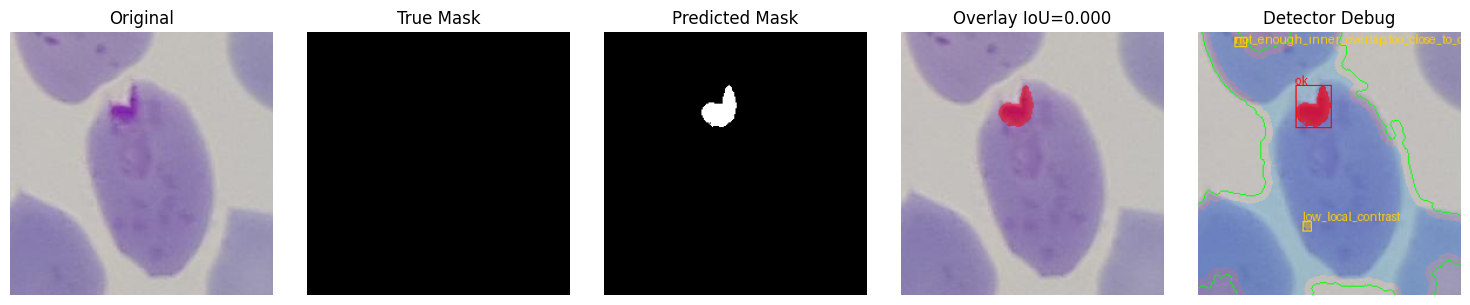

In [12]:
overlay = image.copy()
overlay[true_mask] = (0.5 * overlay[true_mask] + 0.5 * np.array([0, 255, 0])).astype(np.uint8)
overlay[pred_mask] = (0.5 * overlay[pred_mask] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[1].imshow(true_mask, cmap="gray")
axes[1].set_title("True Mask")
axes[2].imshow(pred_mask, cmap="gray")
axes[2].set_title("Predicted Mask")
axes[3].imshow(overlay)
axes[3].set_title(f"Overlay IoU={iou:.3f}")
axes[4].imshow(result["debug_images"]["overlay"])
axes[4].set_title("Detector Debug")
for ax in axes:
    ax.axis("off")
plt.tight_layout()


In [13]:
result["features"]

,cell_id,status,reasons,area,cell_area,area_ratio,equiv_diam,diam_ratio,centroid_y,centroid_x,...,eccentricity,solidity,inside_fraction,inner_fraction,mean_purple_z,mean_saturation,mean_darkness,min_dist_border,dist_border_ratio,purple_contrast
0,0,accepted,,615,32605,0.018862,27.982893,0.137339,66.004878,99.209756,...,0.741203,0.851801,1.0,1.000000,11.268012,0.465054,0.351913,22.627417,0.111055,6.075893
1,0,rejected,not_enough_inner_overlap;too_close_to_cell_border,53,32605,0.001626,8.214724,0.040318,7.566038,35.490566,...,0.757680,0.981481,1.0,0.207547,3.061661,0.248972,0.400414,1.414214,0.006941,5.531342
2,0,rejected,low_local_contrast,37,32605,0.001135,6.863663,0.033687,164.081081,92.324324,...,0.617378,1.000000,1.0,1.000000,2.558835,0.256895,0.351188,44.204072,0.216953,1.823835
